In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from scipy import stats
from scipy.stats import chi2_contingency, f_oneway

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, ConfusionMatrixDisplay)
from sklearn.decomposition import TruncatedSVD
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn.naive_bayes import MultinomialNB
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import xgboost as xgb
import lightgbm as lgb
import statsmodels.api as sm

RANDOM_STATE = 42

## 1.DATA LOADING

In [2]:
train_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
#train_df = pd.read_csv("mlp_project_train.csv")
train_df.shape

(198000, 15)

In [3]:
test_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
#test_df = pd.read_csv("mlp_project_test.csv")
test_df.shape

(102000, 14)

In [4]:
train_df.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [5]:
test_df.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment
0,2024-02-08 13:13:27.998156+00:00,72,2,0,0,4,1,0,10,NaN,NaN,NaN,False,Canada is being run by someone with the mental...
1,2024-03-01 23:33:25.547123+00:00,123,0,0,0,0,0,0,10,NaN,NaN,NaN,False,And your comment is left-wing drivel
2,2024-02-09 21:52:48.426303+00:00,120,0,0,0,3,0,0,4,NaN,NaN,NaN,False,http://talkingpointsmemo..com/dc/special-couns...
3,2024-02-17 03:43:02.980294+00:00,123,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"Trump jl Blames: The Secret Service, James Com..."
4,2024-04-24 02:27:57.145155+00:00,123,0,0,0,0,0,0,11,NaN,NaN,NaN,False,It was hard enough to get the stench out of th...


## 2.EXPLORATORY DATA ANALYSIS

### 2.1 Basic Info

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [7]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  102000 non-null  object
 1   post_id       102000 non-null  int64 
 2   emoticon_1    102000 non-null  int64 
 3   emoticon_2    102000 non-null  int64 
 4   emoticon_3    102000 non-null  int64 
 5   upvote        102000 non-null  int64 
 6   downvote      102000 non-null  int64 
 7   if_1          102000 non-null  int64 
 8   if_2          102000 non-null  int64 
 9   race          26731 non-null   object
 10  religion      26731 non-null   object
 11  gender        26731 non-null   object
 12  disability    102000 non-null  bool  
 13  comment       102000 non-null  object
dtypes: bool(1), int64(8), object(5)
memory usage: 10.2+ MB


In [8]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
post_id,198000.0,68.447429,27.948390,20.0,39.0,72.0,72.0,129.0
emoticon_1,198000.0,0.279768,1.023234,0.0,0.0,0.0,0.0,47.0
emoticon_2,198000.0,0.048338,0.258477,0.0,0.0,0.0,0.0,11.0
emoticon_3,198000.0,0.121071,0.481013,0.0,0.0,0.0,0.0,17.0
upvote,198000.0,2.607975,5.054763,0.0,0.0,1.0,3.0,201.0
downvote,198000.0,0.666394,2.044335,0.0,0.0,0.0,1.0,107.0
if_1,198000.0,1.906152,25.635752,0.0,0.0,0.0,4.0,1860.0
if_2,198000.0,7.956212,14.839464,3.0,4.0,6.0,10.0,1833.0
label,198000.0,0.793965,0.979808,0.0,0.0,0.0,2.0,3.0


In [9]:
test_df.describe().T

,count,mean,std,min,25%,50%,75%,max
post_id,102000.0,68.359422,27.923491,24.0,39.0,72.0,72.0,129.0
emoticon_1,102000.0,0.280078,1.043353,0.0,0.0,0.0,0.0,95.0
emoticon_2,102000.0,0.048353,0.257278,0.0,0.0,0.0,0.0,8.0
emoticon_3,102000.0,0.118902,0.480484,0.0,0.0,0.0,0.0,19.0
upvote,102000.0,2.609402,4.966033,0.0,0.0,1.0,3.0,189.0
downvote,102000.0,0.661667,1.965536,0.0,0.0,0.0,1.0,95.0
if_1,102000.0,1.903078,26.273483,0.0,0.0,0.0,4.0,1866.0
if_2,102000.0,7.956206,15.186746,4.0,4.0,6.0,10.0,1798.0


In [10]:
print("Null count in train:")
print(train_df.isnull().sum().sort_values(ascending=False))

print("Null count in test:")
print(test_df.isnull().sum().sort_values(ascending=False))

Null count in train:
gender          145423
race            145423
religion        145423
comment              1
created_date         0
post_id              0
emoticon_1           0
downvote             0
upvote               0
emoticon_3           0
emoticon_2           0
if_1                 0
if_2                 0
disability           0
label                0
dtype: int64
Null count in test:
religion        75269
race            75269
gender          75269
emoticon_1          0
created_date        0
post_id             0
upvote              0
emoticon_3          0
emoticon_2          0
downvote            0
if_2                0
if_1                0
disability          0
comment             0
dtype: int64


### 2.2 Tagret Distribution

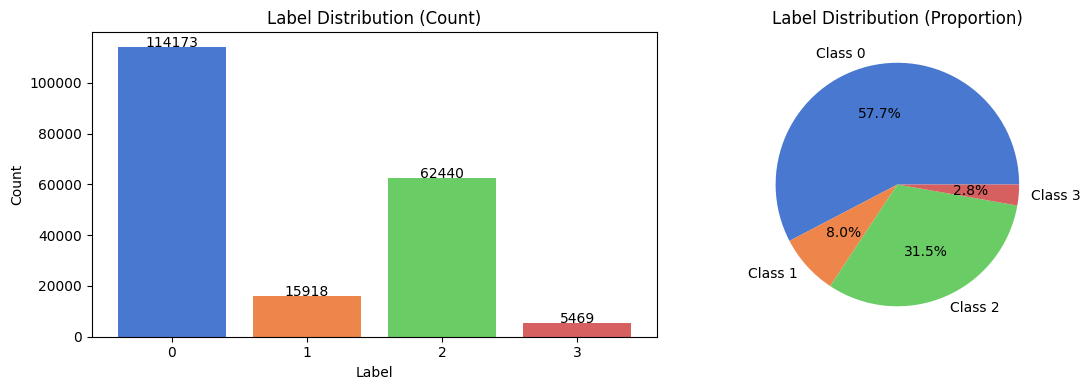

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vc = train_df['label'].value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color=sns.color_palette("muted", 4))
axes[0].set_title("Label Distribution (Count)")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=10)

axes[1].pie(vc.values, labels=[f"Class {i}" for i in vc.index],
            autopct='%1.1f%%', colors=sns.color_palette("muted", 4))
axes[1].set_title("Label Distribution (Proportion)")
plt.tight_layout()
#plt.savefig("eda_01_label_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Temporal Features

In [12]:
### Copies for EDA
train_df_copy = train_df.copy()
test_df_copy = test_df.copy()

#test_df.head()

In [ ]:
train_df_copy['created_date'] = pd.to_datetime(train_df_copy['created_date'], utc=True, errors='coerce')
test_df_copy['created_date'] = pd.to_datetime(test_df_copy['created_date'],  utc=True, errors='coerce')

train_df_copy['hour'] = train_df_copy['created_date'].dt.hour
train_df_copy['dayofweek'] = train_df_copy['created_date'].dt.dayofweek
train_df_copy['month'] = train_df_copy['created_date'].dt.month
train_df_copy['year'] = train_df_copy['created_date'].dt.year

test_df_copy['hour'] = test_df_copy['created_date'].dt.hour
test_df_copy['dayofweek'] = test_df_copy['created_date'].dt.dayofweek
test_df_copy['month'] = test_df_copy['created_date'].dt.month
test_df_copy['year'] = test_df_copy['created_date'].dt.year

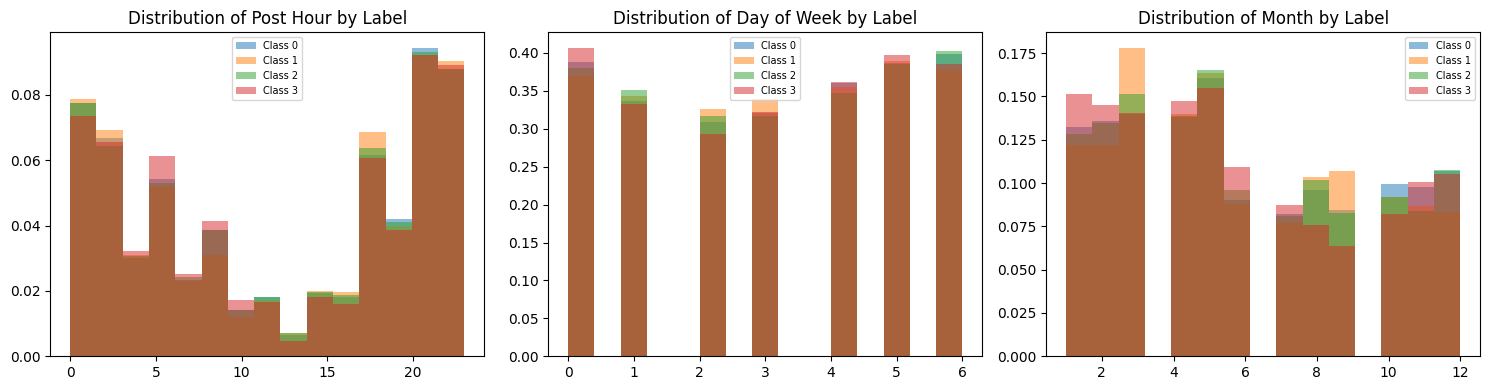

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes,
                           ['hour', 'dayofweek', 'month'],
                           ['Post Hour', 'Day of Week', 'Month']):
    for label_val in sorted(train_df_copy['label'].unique()):
        sub = train_df_copy[train_df_copy['label'] == label_val]
        ax.hist(sub[col], bins=15, alpha=0.5, label=f"Class {label_val}", density=True)
    ax.set_title(f"Distribution of {title} by Label")
    ax.legend(fontsize=7)
plt.tight_layout()
#plt.savefig("eda_02_temporal.png", dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Numerical Feature Distributions

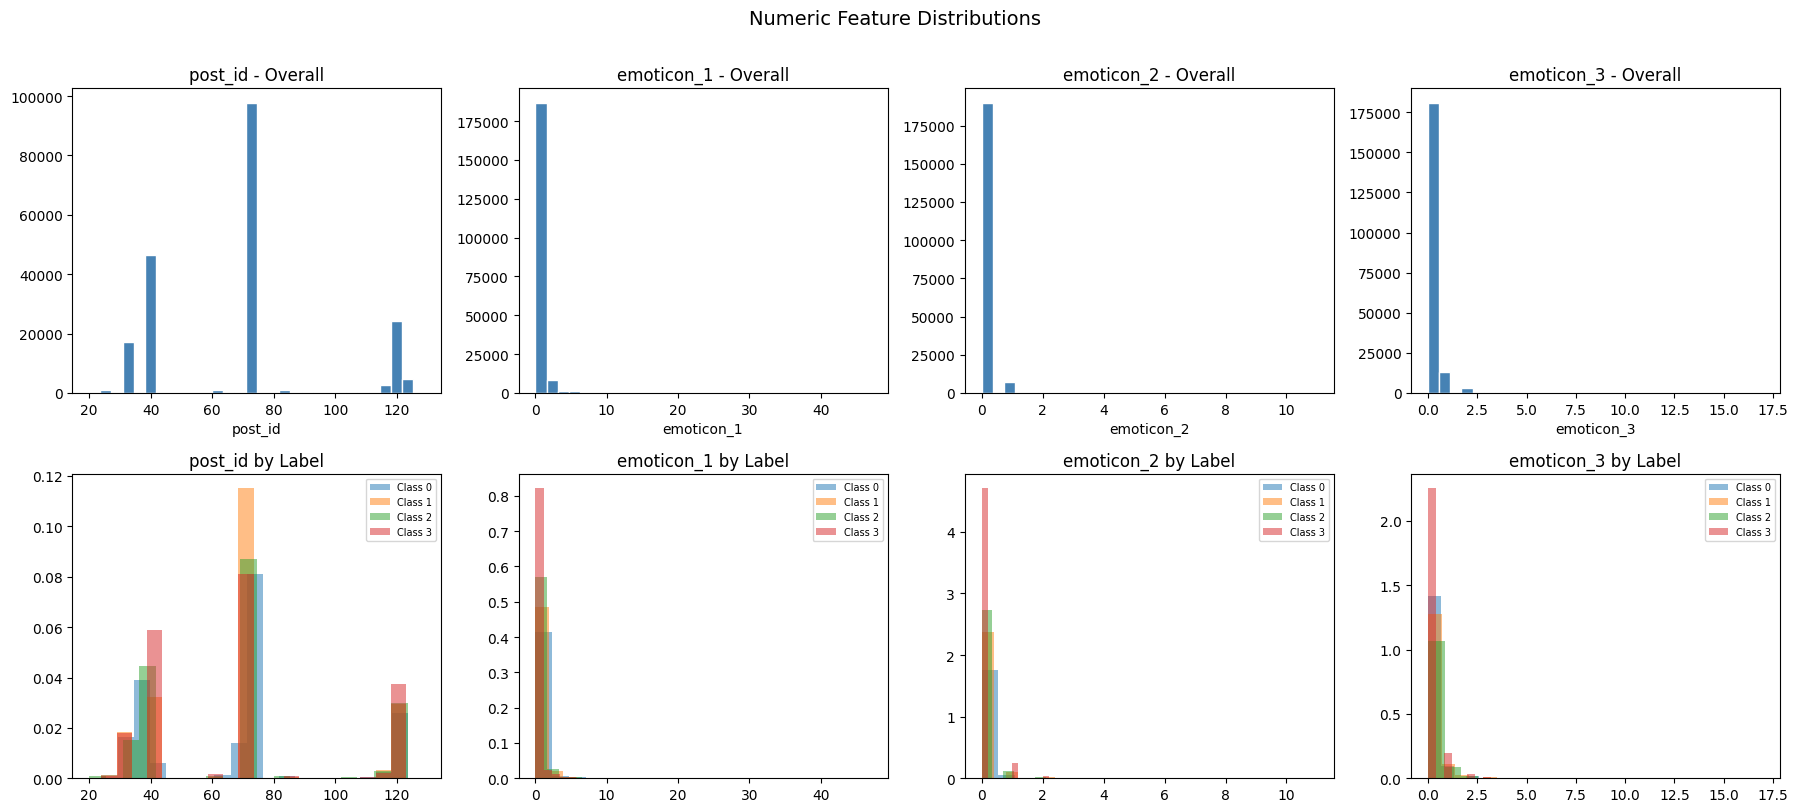

In [15]:
num_cols_1 = ['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(num_cols_1):
    axes[0, i].hist(train_df[col], bins=30, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f"{col} - Overall")
    axes[0, i].set_xlabel(col)

    for lv in sorted(train_df['label'].unique()):
        axes[1, i].hist(train_df.loc[train_df['label'] == lv, col],
                        bins=20, alpha=0.5, label=f"Class {lv}", density=True)
    axes[1, i].set_title(f"{col} by Label")
    axes[1, i].legend(fontsize=7)
plt.suptitle("Numeric Feature Distributions", fontsize=14, y=1.01)
plt.tight_layout()
#plt.savefig("eda_03_numeric_dist_1.png", dpi=150, bbox_inches='tight')
plt.show()


Emoticon columns — numerical analysis
          emoticon_1     emoticon_2     emoticon_3
count  198000.000000  198000.000000  198000.000000
mean        0.279768       0.048338       0.121071
std         1.023234       0.258477       0.481013
min         0.000000       0.000000       0.000000
25%         0.000000       0.000000       0.000000
50%         0.000000       0.000000       0.000000
75%         0.000000       0.000000       0.000000
max        47.000000      11.000000      17.000000


/tmp/ipykernel_17/1560793865.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_label,
/tmp/ipykernel_17/1560793865.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_label,
/tmp/ipykernel_17/1560793865.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_label,


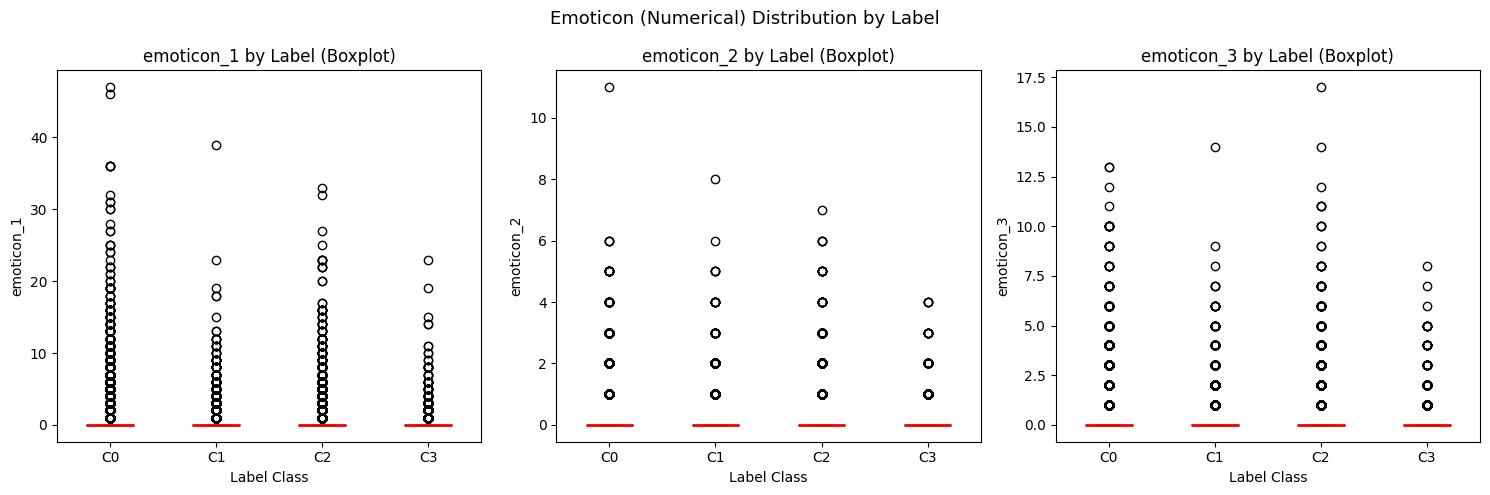

In [16]:
print("Emoticon columns — numerical analysis")
print(train_df[['emoticon_1', 'emoticon_2', 'emoticon_3']].describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['emoticon_1', 'emoticon_2', 'emoticon_3']):
    data_by_label = [train_df.loc[train_df['label'] == lv, col].values
                     for lv in sorted(train_df['label'].unique())]
    bp = ax.boxplot(data_by_label,
                    labels=[f"C{i}" for i in sorted(train_df['label'].unique())],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightsteelblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    ax.set_title(f"{col} by Label (Boxplot)")
    ax.set_xlabel("Label Class")
    ax.set_ylabel(col)
plt.suptitle("Emoticon (Numerical) Distribution by Label", fontsize=13)
plt.tight_layout()
#plt.savefig("eda_05_emoticon_numerical.png", dpi=150, bbox_inches='tight')
plt.show()

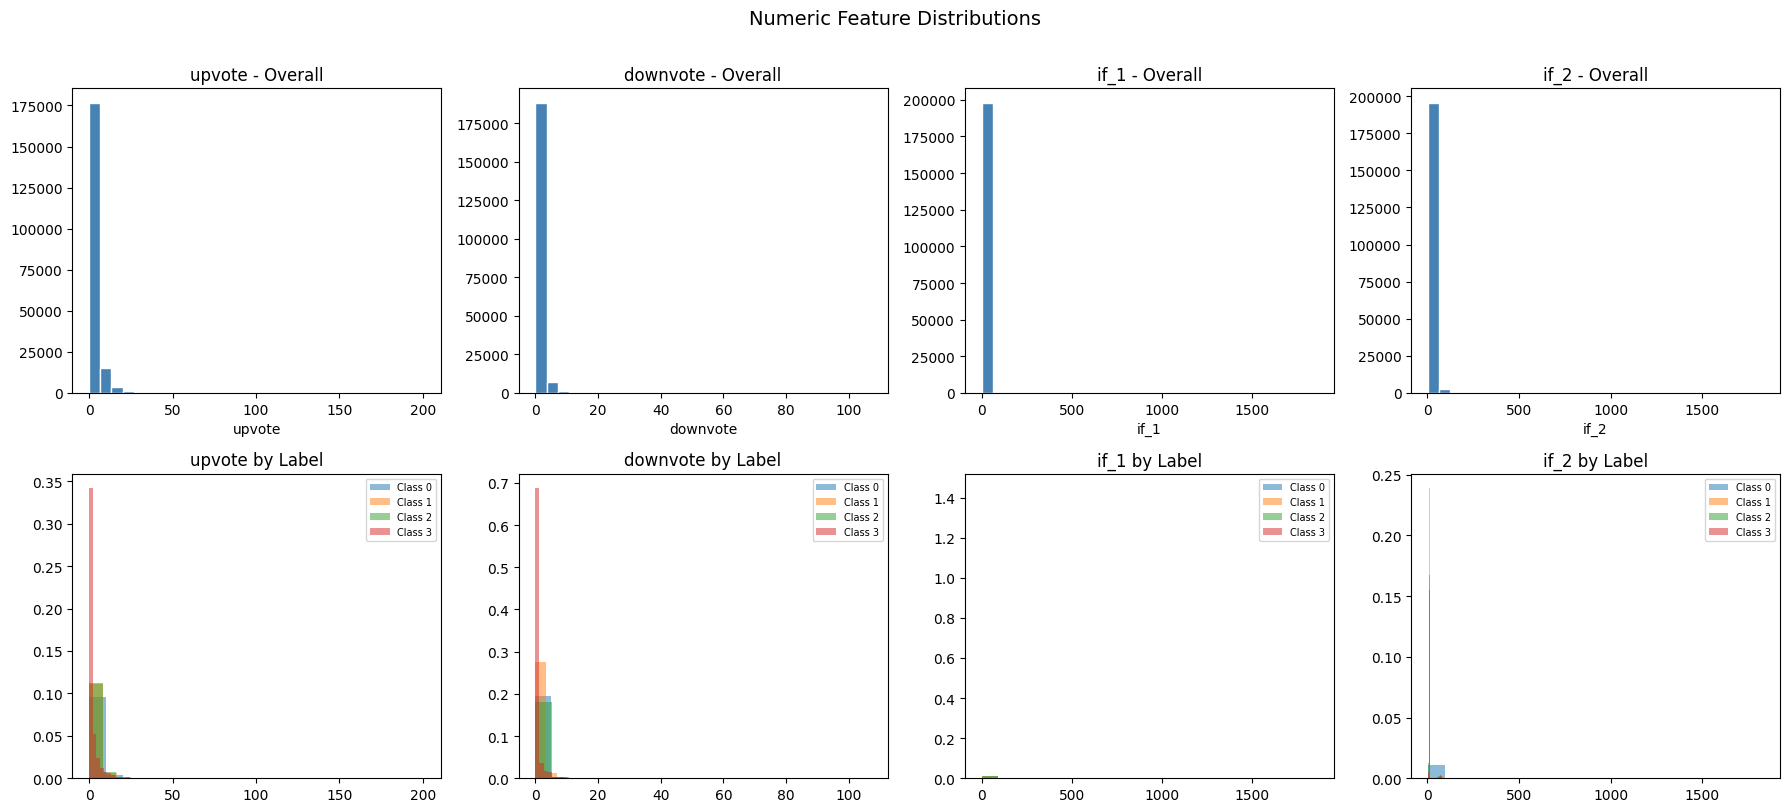

In [17]:
num_cols_2 = ['upvote', 'downvote', 'if_1', 'if_2']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(num_cols_2):
    axes[0, i].hist(train_df[col], bins=30, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f"{col} - Overall")
    axes[0, i].set_xlabel(col)

    for lv in sorted(train_df['label'].unique()):
        axes[1, i].hist(train_df.loc[train_df['label'] == lv, col],
                        bins=20, alpha=0.5, label=f"Class {lv}", density=True)
    axes[1, i].set_title(f"{col} by Label")
    axes[1, i].legend(fontsize=7)
plt.suptitle("Numeric Feature Distributions", fontsize=14, y=1.01)
plt.tight_layout()
#plt.savefig("eda_03_numeric_dist_2.png", dpi=150, bbox_inches='tight')
plt.show()



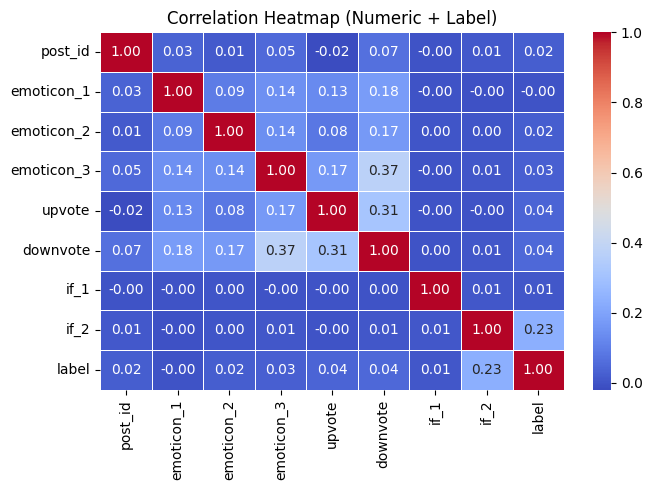

In [18]:
num_cols = ['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3','upvote', 'downvote', 'if_1', 'if_2']
corr_df = train_df[num_cols + ['label']].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap (Numeric + Label)")
plt.tight_layout()
#plt.savefig("eda_04_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

### 2.5 Categorical/Binary Features

In [19]:
cat_cols = ['race', 'religion', 'gender', 'disability']

# Encode disability (TRUE/FALSE string → 1/0)
train_df_copy['disability_bin'] = train_df_copy['disability'].map({
    'TRUE': 1, 'False': 0, 'FALSE': 0,
    True: 1, False: 0}).fillna(0).astype(int)
test_df_copy['disability_bin'] = test_df_copy['disability'].map({
    'TRUE': 1, 'False': 0, 'FALSE': 0,
    True: 1, False: 0}).fillna(0).astype(int)


In [20]:
# Chi-square test
print("Chi-Square Tests (categorical vs label)")
for col in ['race', 'religion', 'gender']:
    cleaned = train_df[col].fillna('none').astype(str)
    ct_table = pd.crosstab(cleaned, train_df['label'])
    chi2, p, dof, _ = chi2_contingency(ct_table)
    print(f"  {col:10s}: chi2={chi2:.2f}, p={p:.4f} {'*SIGNIFICANT*' if p < 0.05 else ''}")

Chi-Square Tests (categorical vs label)
  race      : chi2=45429.25, p=0.0000 *SIGNIFICANT*
  religion  : chi2=32056.84, p=0.0000 *SIGNIFICANT*
  gender    : chi2=10201.96, p=0.0000 *SIGNIFICANT*


### 2.6 Text-Feature Analysis

In [21]:
train_df_copy['comment'] = train_df_copy['comment'].fillna('').astype(str)
test_df_copy['comment']  = test_df_copy['comment'].fillna('').astype(str)

train_df_copy['text_len'] = train_df_copy['comment'].str.len()
train_df_copy['word_count'] = train_df_copy['comment'].str.split().str.len()
train_df_copy['avg_word_len'] = train_df_copy['comment'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0)
train_df_copy['exclaim_count'] = train_df_copy['comment'].str.count('!')
train_df_copy['question_count'] = train_df_copy['comment'].str.count(r'\?')
train_df_copy['caps_ratio'] = train_df_copy['comment'].apply(
    lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))
train_df_copy['unique_word_ratio'] = train_df_copy['comment'].apply(
    lambda x: len(set(x.lower().split())) / max(len(x.split()), 1))

train_df_copy['has_url'] = train_df_copy['comment'].str.contains(
    r'http[s]?://', flags=re.IGNORECASE).astype(int)

train_df_copy['has_quote'] = train_df_copy['comment'].str.contains('"').astype(int)

test_df_copy['text_len'] = test_df_copy['comment'].str.len()
test_df_copy['word_count'] = test_df_copy['comment'].str.split().str.len()
test_df_copy['avg_word_len'] = test_df_copy['comment'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0)

test_df_copy['exclaim_count'] = test_df_copy['comment'].str.count('!')
test_df_copy['question_count'] = test_df_copy['comment'].str.count(r'\?')
test_df_copy['caps_ratio'] = test_df_copy['comment'].apply(
    lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))
test_df_copy['unique_word_ratio'] = test_df_copy['comment'].apply(
    lambda x: len(set(x.lower().split())) / max(len(x.split()), 1))
test_df_copy['has_url'] = test_df_copy['comment'].str.contains(
    r'http[s]?://', flags=re.IGNORECASE).astype(int)
test_df_copy['has_quote'] = test_df_copy['comment'].str.contains('"').astype(int)


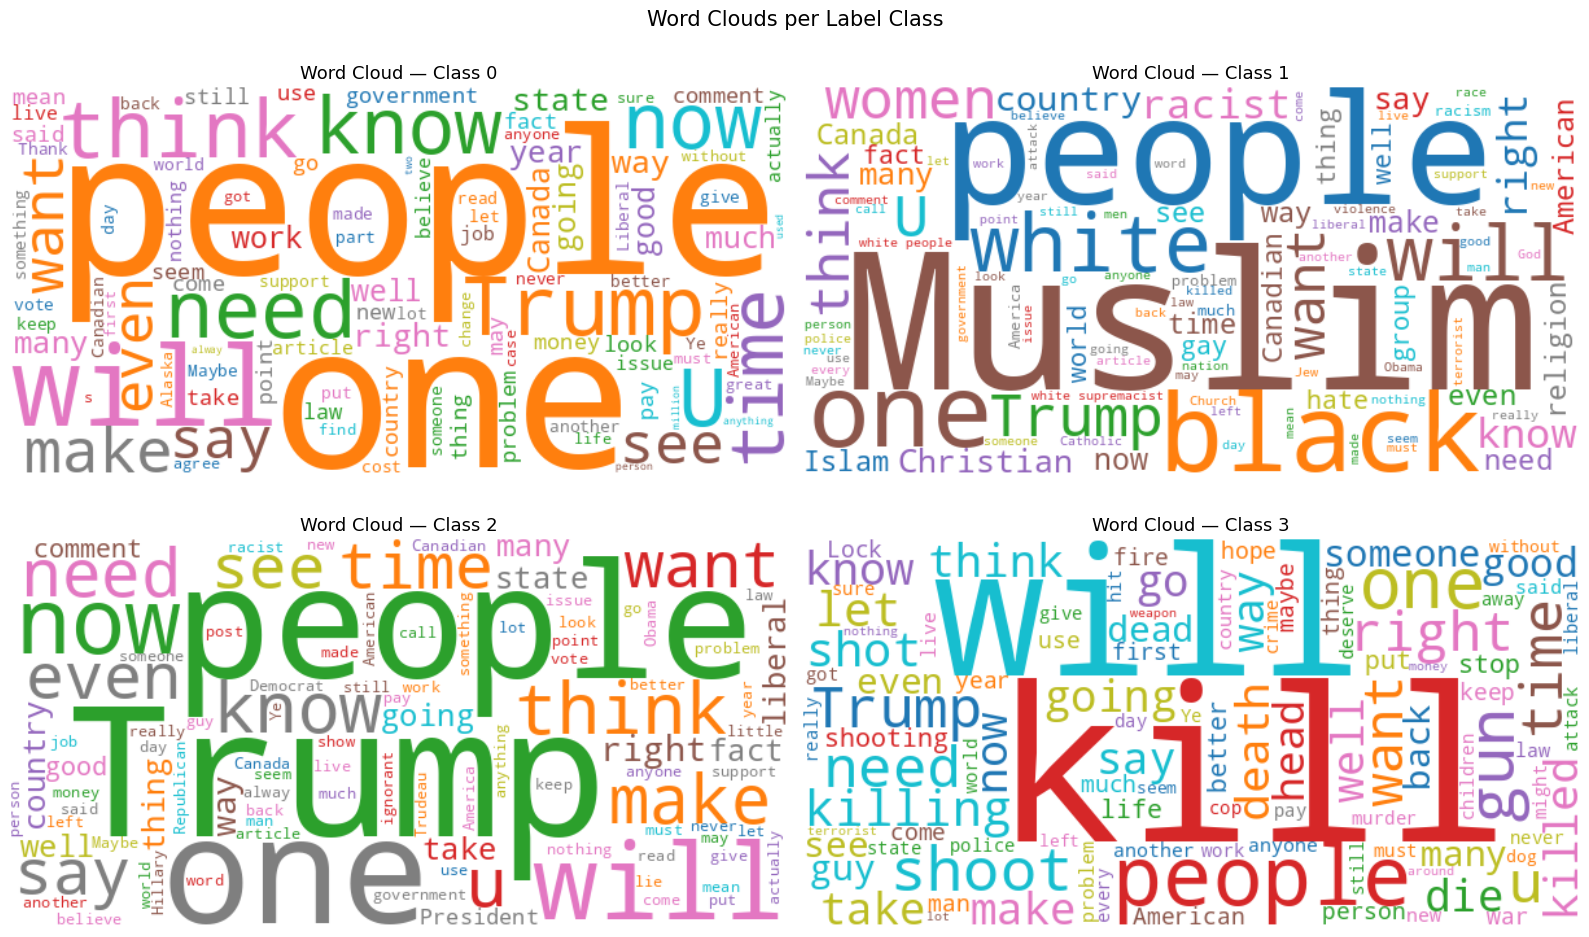

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, lv in zip(axes.flatten(), sorted(train_df_copy['label'].unique())):
    text = " ".join(train_df_copy.loc[train_df_copy['label'] == lv, 'comment'])
    wc = WordCloud(width=600, height=300, background_color='white',
                   max_words=100, colormap='tab10').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f"Word Cloud — Class {lv}", fontsize=13)
plt.suptitle("Word Clouds per Label Class", fontsize=15)
plt.tight_layout()
#plt.savefig("eda_07_wordclouds.png", dpi=150, bbox_inches='tight')
plt.show()

### 2.8 Post_id Distribution

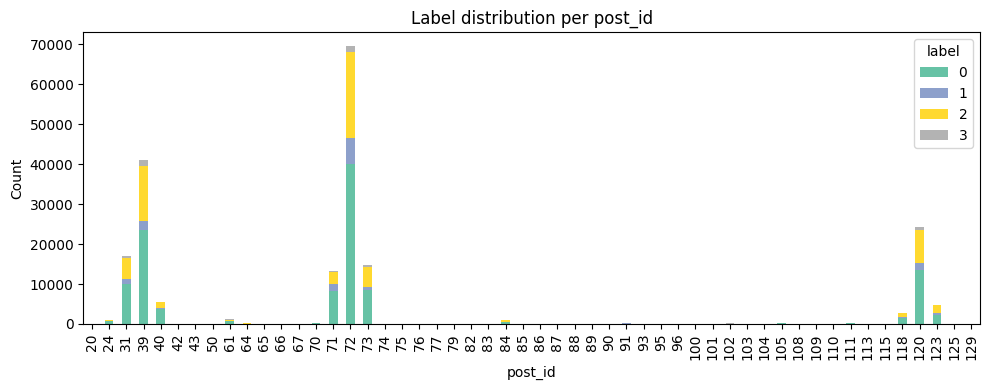

In [23]:
fig, ax = plt.subplots(figsize=(10, 4))
post_label = train_df.groupby(['post_id', 'label']).size().unstack(fill_value=0)
post_label.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_title("Label distribution per post_id")
ax.set_xlabel("post_id")
ax.set_ylabel("Count")
plt.tight_layout()
#plt.savefig("eda_08_postid_label.png", dpi=150, bbox_inches='tight')
plt.show()
# print("post_id encodes thread-level context — certain threads attract certain label types.")


### 2.9 Comment Length by Class

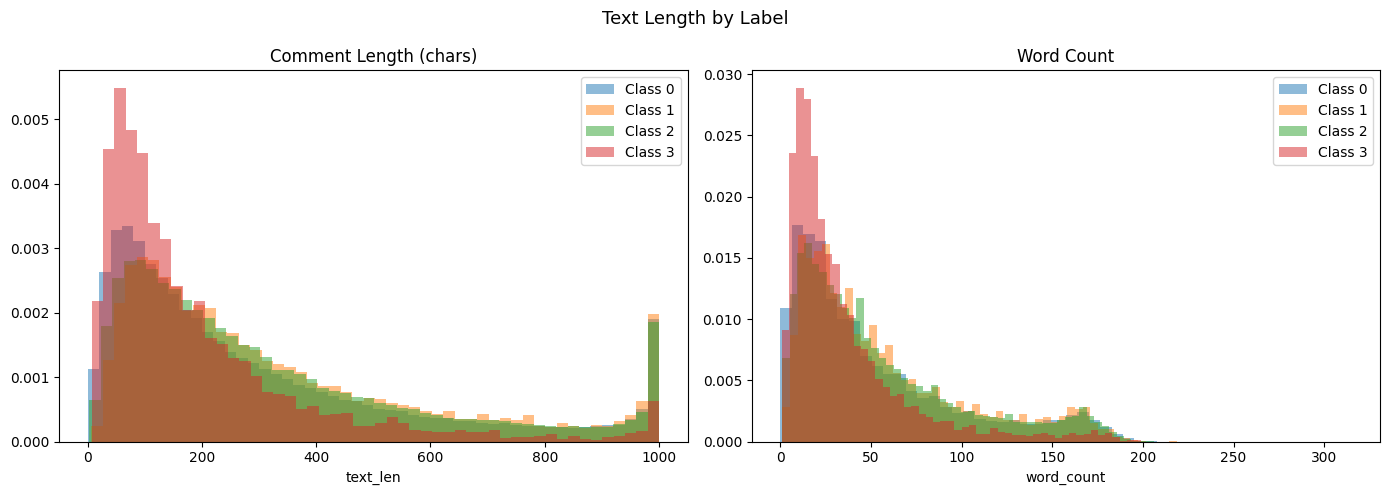

Mean text stats by class:
       text_len  word_count
label                      
0         295.9        51.2
1         335.7        57.2
2         316.9        54.9
3         194.2        35.0


In [24]:
train_df_copy['text_len'] = train_df_copy['comment'].str.len()
train_df_copy['word_count'] = train_df_copy['comment'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes,
                           ['text_len', 'word_count'],
                           ['Comment Length (chars)', 'Word Count']):
    for lv in sorted(train_df_copy['label'].unique()):
        vals = train_df_copy.loc[train_df_copy['label']==lv, col].clip(upper=1000)
        ax.hist(vals, bins=50, alpha=0.5, label=f'Class {lv}', density=True)
    ax.set_title(title); ax.legend(); ax.set_xlabel(col)
plt.suptitle('Text Length by Label', fontsize=13)
plt.tight_layout(); plt.show()

print('Mean text stats by class:')
print(train_df_copy.groupby('label')[['text_len','word_count']].mean().round(1))


### 2.10 Vote Patterns by Class

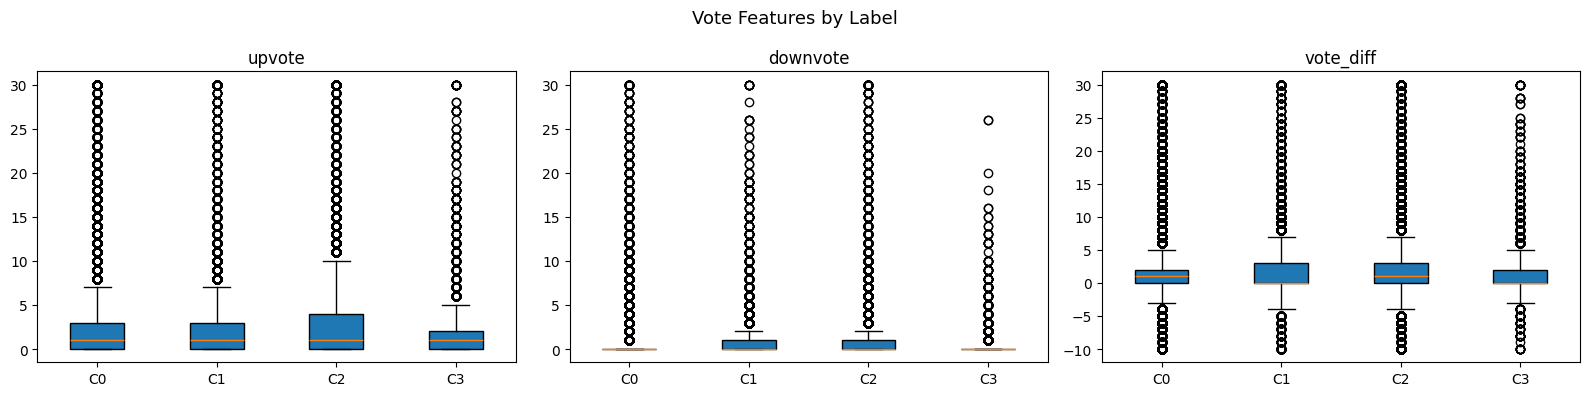

Vote means by class:
       upvote  downvote  vote_diff
label                             
0        2.40      0.58       1.83
1        2.85      0.80       2.05
2        2.97      0.81       2.16
3        2.04      0.51       1.52


In [25]:
import numpy as np
train_df_copy['vote_diff'] = train_df_copy['upvote'] - train_df_copy['downvote']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['upvote', 'downvote', 'vote_diff']):
    data = [train_df_copy.loc[train_df_copy['label']==lv, col].clip(-10, 30).values
            for lv in sorted(train_df_copy['label'].unique())]
    ax.boxplot(data, tick_labels=[f'C{i}' for i in range(4)], patch_artist=True)
    ax.set_title(col)
plt.suptitle('Vote Features by Label', fontsize=13)
plt.tight_layout(); plt.show()

print('Vote means by class:')
print(train_df_copy.groupby('label')[['upvote','downvote','vote_diff']].mean().round(2))

### 2.11 if_1 and if_2 — Class 2 vs Class 3

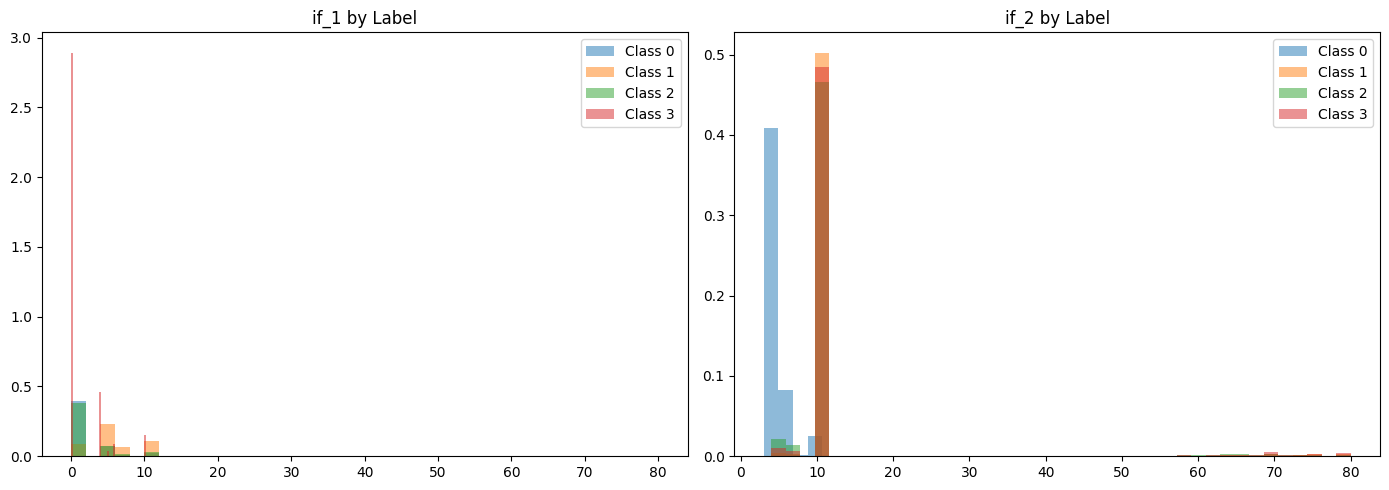

if_1 / if_2 — Class 2 vs Class 3:
          if_1                                              if_2         \
         count  mean    std  min  25%  50%  75%     max    count   mean   
label                                                                     
2      62440.0  1.53  17.56  0.0  0.0  0.0  0.0  1848.0  62440.0  12.21   
3       5469.0  1.13   2.47  0.0  0.0  0.0  0.0    11.0   5469.0  12.62   

                                            
         std  min   25%   50%   75%    max  
label                                       
2      11.88  4.0  10.0  10.0  10.0  110.0  
3      12.77  4.0  10.0  10.0  10.0  123.0  

Class 3 if_1 max: 11
Class 2 if_1 max: 1848


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['if_1', 'if_2']):
    for lv in sorted(train_df_copy['label'].unique()):
        vals = train_df_copy.loc[train_df_copy['label']==lv, col].clip(upper=80)
        ax.hist(vals, bins=40, alpha=0.5, label=f'Class {lv}', density=True)
    ax.set_title(f'{col} by Label'); ax.legend()
plt.tight_layout(); plt.show()

print('if_1 / if_2 — Class 2 vs Class 3:')
print(train_df_copy[train_df_copy['label'].isin([2,3])].groupby('label')[['if_1','if_2']].describe().round(2))
print(f"\nClass 3 if_1 max: {train_df_copy[train_df_copy['label']==3]['if_1'].max()}")
print(f"Class 2 if_1 max: {train_df_copy[train_df_copy['label']==2]['if_1'].max()}")


### 2.12 Emoticon usage by class

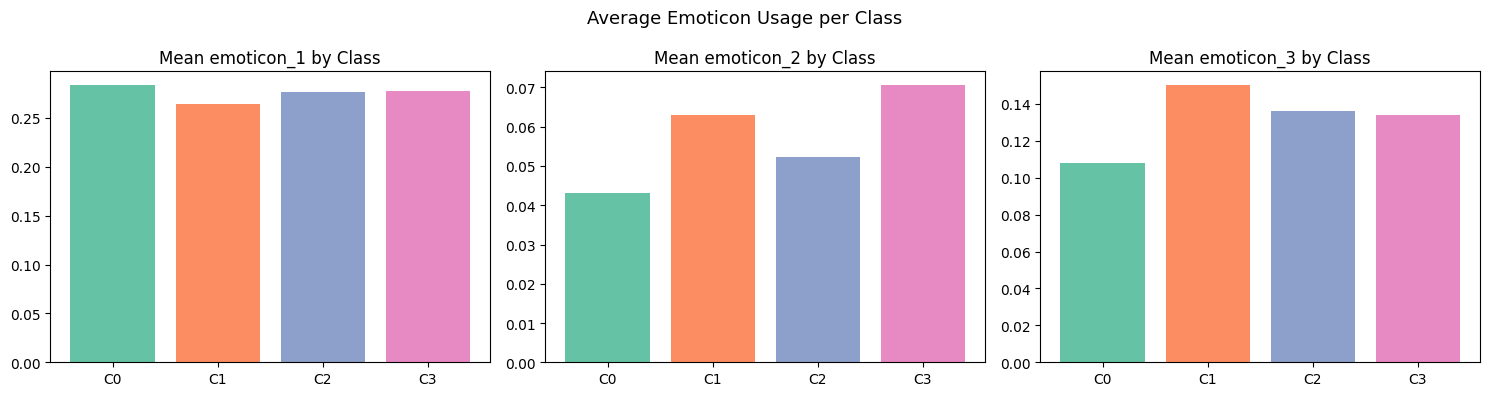

Emoticon means by class:
       emoticon_1  emoticon_2  emoticon_3
label                                    
0           0.284       0.043       0.108
1           0.265       0.063       0.150
2           0.277       0.052       0.136
3           0.277       0.071       0.134


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['emoticon_1', 'emoticon_2', 'emoticon_3']):
    means = train_df_copy.groupby('label')[col].mean()
    ax.bar([f'C{i}' for i in means.index], means.values,
           color=sns.color_palette('Set2', 4))
    ax.set_title(f'Mean {col} by Class')
plt.suptitle('Average Emoticon Usage per Class', fontsize=13)
plt.tight_layout(); plt.show()

print('Emoticon means by class:')
print(train_df_copy.groupby('label')[['emoticon_1','emoticon_2','emoticon_3']].mean().round(3))

### 2.13 Race / Religion / Gender vs Label


RACE distribution by label (row %):
label       0      1      2      3
race                              
asian   0.451  0.288  0.241  0.019
black   0.157  0.692  0.143  0.007
latino  0.440  0.321  0.230  0.010
none    0.600  0.048  0.323  0.029
other   0.409  0.296  0.274  0.022
white   0.168  0.608  0.212  0.011


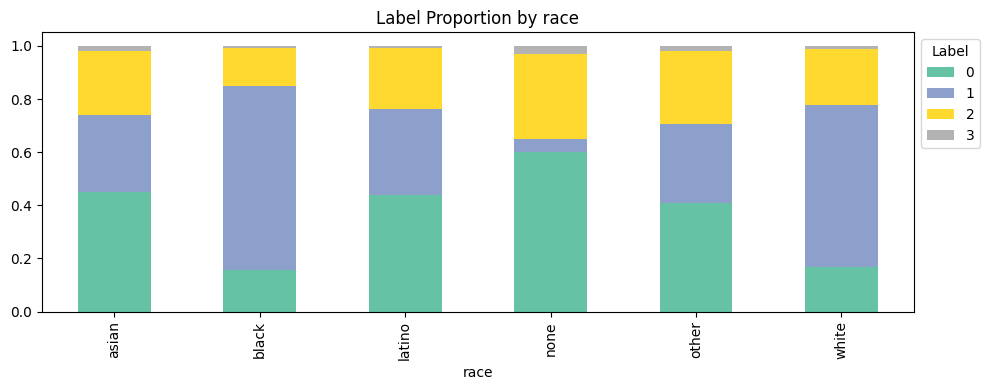


RELIGION distribution by label (row %):
label          0      1      2      3
religion                             
atheist    0.388  0.324  0.260  0.027
buddhist   0.430  0.390  0.170  0.010
christian  0.481  0.300  0.208  0.010
hindu      0.515  0.299  0.175  0.010
jewish     0.280  0.541  0.169  0.010
muslim     0.196  0.636  0.148  0.020
none       0.594  0.052  0.325  0.029
other      0.333  0.400  0.247  0.020


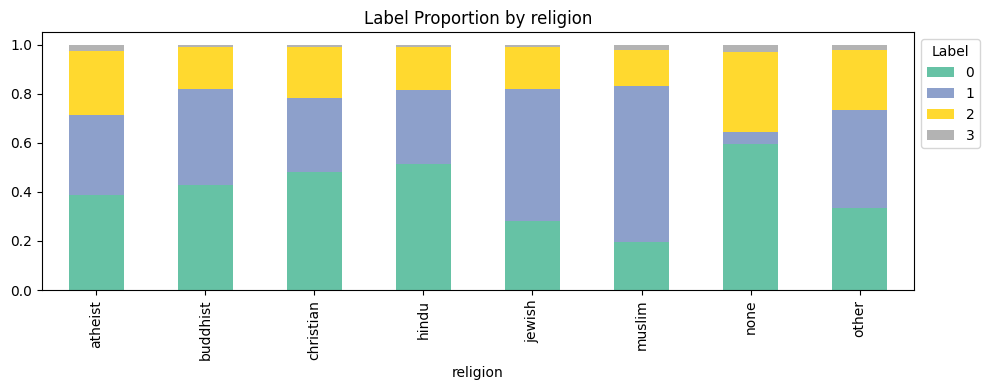


GENDER distribution by label (row %):
label            0      1      2      3
gender                                 
female       0.429  0.244  0.302  0.025
male         0.365  0.284  0.328  0.023
none         0.593  0.063  0.316  0.028
other        0.361  0.380  0.240  0.019
transgender  0.280  0.527  0.185  0.008


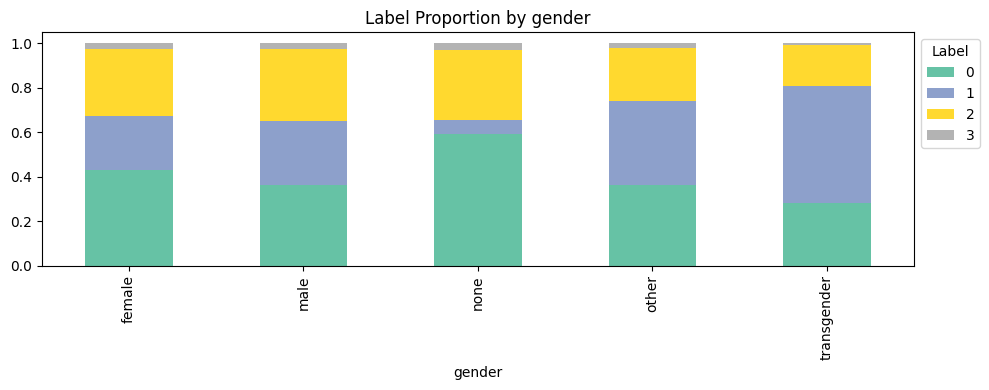

In [28]:
for col in ['race', 'religion', 'gender']:
    print(f"\n{col.upper()} distribution by label (row %):")
    ct = pd.crosstab(
        train_df_copy[col].fillna('none'),
        train_df_copy['label'],
        normalize='index'
    ).round(3)
    print(ct)
    fig, ax = plt.subplots(figsize=(10, 4))
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
    ax.set_title(f'Label Proportion by {col}')
    ax.set_xlabel(col); ax.legend(title='Label', bbox_to_anchor=(1,1))
    plt.tight_layout(); plt.show()


### 2.14 ANOVA - Feature Significance vs Label

   Feature  F-stat  p-value Significant
      if_2 4168.08  0.00000         yes
  text_len  471.06  0.00000         yes
word_count  414.76  0.00000         yes
      if_1  330.20  0.00000         yes
  downvote  214.92  0.00000         yes
    upvote  203.12  0.00000         yes
 vote_diff   78.33  0.00000         yes
emoticon_3   68.11  0.00000         yes
emoticon_2   51.07  0.00000         yes
emoticon_1    1.85  0.13517          no


/tmp/ipykernel_17/2074824755.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=anova_df, y='Feature', x='F-stat', palette='Blues_r')


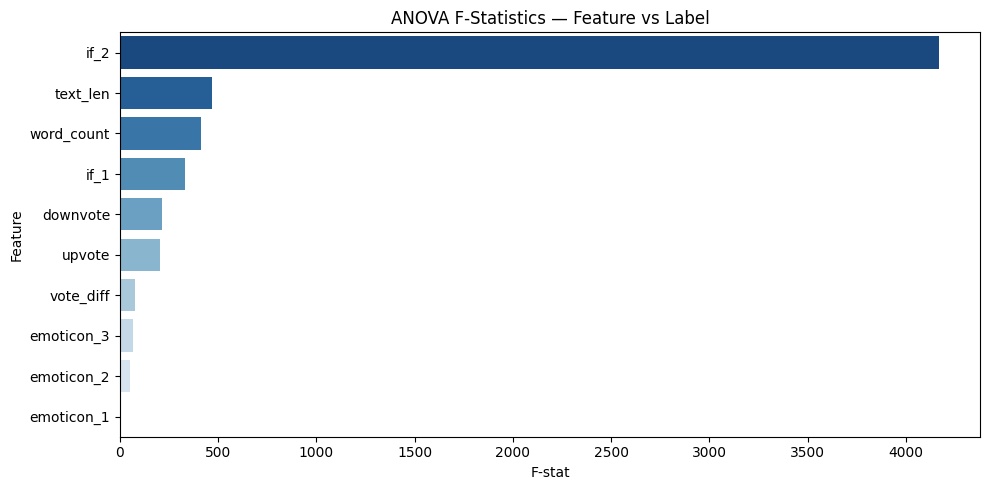

In [29]:
from scipy.stats import f_oneway

anova_cols = ['upvote','downvote','if_1','if_2',
              'emoticon_1','emoticon_2','emoticon_3',
              'vote_diff','text_len','word_count']

rows = []
for col in anova_cols:
    if col in train_df_copy.columns:
        groups = [train_df_copy.loc[train_df_copy['label']==lv, col].dropna().values
                  for lv in sorted(train_df_copy['label'].unique())]
        f_stat, p_val = f_oneway(*groups)
        rows.append({'Feature': col, 'F-stat': round(f_stat,2),
                     'p-value': round(p_val,5),
                     'Significant': 'yes' if p_val < 0.01 else 'no'})

anova_df = pd.DataFrame(rows).sort_values('F-stat', ascending=False)
print(anova_df.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=anova_df, y='Feature', x='F-stat', palette='Blues_r')
plt.title('ANOVA F-Statistics — Feature vs Label')
plt.tight_layout(); plt.show()


## 3. PREPROCESSING

### 3.1 Feature Extraction

In [30]:
def preprocess(df):
    df = df.copy()

    ## Date
    df['created_date'] = pd.to_datetime(df['created_date'], utc=True, errors='coerce')
    df['hour'] = df['created_date'].dt.hour
    df['dayofweek'] = df['created_date'].dt.dayofweek
    df['month'] = df['created_date'].dt.month
    df['year'] = df['created_date'].dt.year 
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)
    df.drop(columns=['created_date'], inplace=True)

    ## Fill null values
    df['race'] = df['race'].fillna('none').str.lower().str.strip()
    df['religion'] = df['religion'].fillna('none').str.lower().str.strip()
    df['gender'] = df['gender'].fillna('none').str.lower().str.strip()
    df['comment'] = df['comment'].fillna('')
    df['disability'] = df['disability'].astype(int)
    
    ## Vote Features
    df['vote_diff'] = df['upvote'] - df['downvote']
    df['vote_ratio'] = np.log1p(df['upvote']) - np.log1p(df['downvote'])
    df['total_votes'] = df['upvote'] + df['downvote']
    
    ## Group target flags
    df['race_none'] = (df['race'] == 'none').astype(int)
    df['religion_none'] = (df['religion'] == 'none').astype(int)
    df['gender_none'] = (df['gender']   == 'none').astype(int)
    df['no_target'] = (df['race_none'] & df['religion_none'] & df['gender_none']).astype(int)
  
    return df

train_df = preprocess(train_df)
test_df = preprocess(test_df)
print(f"Train: {train_df.shape} | Test: {test_df.shape}")      


Train: (198000, 27) | Test: (102000, 26)


In [31]:
# Drop if already exists (to rerun safely)
post_agg_cols = ['post_comment_count', 'post_avg_upvote', 'post_avg_downvote',
                 'post_total_votes'] 
train_df = train_df.drop(columns=[c for c in post_agg_cols if c in train_df.columns])
test_df = test_df.drop(columns=[c for c in post_agg_cols if c in test_df.columns])

train_df['total_votes_tmp'] = train_df['upvote'] + train_df['downvote']

post_stats = train_df.groupby('post_id').agg(
    post_comment_count = ('comment','count'),
    post_avg_upvote = ('upvote','mean'),
    post_avg_downvote = ('downvote','mean'),
    post_total_votes = ('total_votes_tmp','sum'),
).reset_index()

train_df.drop(columns=['total_votes_tmp'], inplace=True)
train_df = train_df.merge(post_stats, on='post_id', how='left')
test_df = test_df.merge(post_stats,  on='post_id', how='left')

fallback = {col: train_df[col].median() for col in post_agg_cols}

for col, val in fallback.items():
    train_df[col] = train_df[col].fillna(val)
    test_df[col] = test_df[col].fillna(val)

print(f"post_id agg features added: {post_agg_cols}")
print(f"Train shape: {train_df.shape}")

post_id agg features added: ['post_comment_count', 'post_avg_upvote', 'post_avg_downvote', 'post_total_votes']
Train shape: (198000, 31)


### 3.2 Transformers and Encoders

In [32]:
# Numeric cols — everything except comment/race/religion/gender/label
EXCLUDE = ['comment', 'race', 'religion', 'gender', 'label']
numeric_cols = [c for c in train_df.columns
                if c not in EXCLUDE
                and train_df[c].dtype in [np.float64, np.int64, np.int32, np.float32]]

print(f"Numeric cols ({len(numeric_cols)}): {numeric_cols}")

preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(
            max_features=10000,
            ngram_range=(3, 5),
            sublinear_tf=True,
            min_df=3,
            analyzer='char_wb'
            #stop_words='english'
        ), 'comment'),
        ('ohe', OneHotEncoder(
            drop='first',
            handle_unknown='ignore',
            sparse_output=True
        ), ['race', 'religion', 'gender']),
    ],
    remainder='passthrough'   # numeric cols passed through automatically
)

y = train_df['label'].values
df_fit = train_df.drop(columns=['label'])

X = preprocessor.fit_transform(df_fit)
X_test = preprocessor.transform(test_df)
print(f"Feature matrix : {X.shape}")
print(f"Label dist : {np.bincount(y)}")

Numeric cols (26): ['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'disability', 'hour', 'dayofweek', 'month', 'year', 'is_weekend', 'is_night', 'vote_diff', 'vote_ratio', 'total_votes', 'race_none', 'religion_none', 'gender_none', 'no_target', 'post_comment_count', 'post_avg_upvote', 'post_avg_downvote', 'post_total_votes']
Feature matrix : (198000, 10042)
Label dist : [114173  15918  62440   5469]


## 4. TRAIN TEST SPLIT

### 4.1 For Boosting models

In [33]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
print(f"Train : {X_tr.shape} | {np.bincount(y_tr)}")
print(f"Val : {X_val.shape} | {np.bincount(y_val)}")

# Class weights — no SMOTE to avoid memory error on sparse matrix
n_tr = len(y_tr)
cnt_tr = np.bincount(y_tr)
weights = {i: n_tr / (4 * cnt_tr[i]) for i in range(4)}
print(f"Class weights: {weights}")

Train : (158400, 10042) | [91338 12735 49952  4375]
Val : (39600, 10042) | [22835  3183 12488  1094]
Class weights: {0: np.float64(0.4335544899165736), 1: np.float64(3.1095406360424027), 2: np.float64(0.7927610506085843), 3: np.float64(9.051428571428572)}


### 4.2 For Naive Bayes

In [34]:
# Keep only non-negative numeric columns for NB
train_df_nb = train_df.select_dtypes(include='number').copy()
train_df_nb = train_df_nb.loc[:, (train_df_nb >= 0).all()]

test_df_nb  = test_df.select_dtypes(include='number').copy()
test_df_nb = test_df_nb.loc[:, (test_df_nb >= 0).all()]
# Use same columns as train (test may differ slightly)
nb_cols     = train_df_nb.columns.tolist()

# Remove label from features if present
if 'label' in nb_cols:
    nb_cols.remove('label')

X_nb = train_df_nb[nb_cols].values
y_nb = train_df['label'].values
X_test_nb = test_df[nb_cols].fillna(0).values

print(f"NB feature columns ({len(nb_cols)}): {nb_cols}")
print(f"X_nb shape : {X_nb.shape}")
print(f"y_nb dist  : {np.bincount(y_nb)}")

X_tr_nb, X_val_nb, y_tr_nb, y_val_nb = train_test_split(
    X_nb, y_nb,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_nb
)
print(f"Train : {X_tr_nb.shape} | {np.bincount(y_tr_nb)}")
print(f"Val   : {X_val_nb.shape} | {np.bincount(y_val_nb)}")

NB feature columns (24): ['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'disability', 'hour', 'dayofweek', 'month', 'year', 'is_weekend', 'is_night', 'total_votes', 'race_none', 'religion_none', 'gender_none', 'no_target', 'post_comment_count', 'post_avg_upvote', 'post_avg_downvote', 'post_total_votes']
X_nb shape : (198000, 24)
y_nb dist  : [114173  15918  62440   5469]
Train : (158400, 24) | [91338 12735 49952  4375]
Val   : (39600, 24) | [22835  3183 12488  1094]


## 5. MODELS

## 5.1 LightBGM

#### Hyperparameter Tuning

```
from sklearn.model_selection import GridSearchCV

param_grid_lgb = {
    'n_estimators': [200, 400],
    'num_leaves':   [31, 63],
    'learning_rate':[0.05, 0.1],
}

lgb_search = GridSearchCV(
    lgb.LGBMClassifier(
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight=weights,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=-1
    ),
    param_grid=param_grid_lgb,
    cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro',
    n_jobs=1,
    verbose=2
)
lgb_search.fit(X_tr, y_tr)

print(f"Best LGB params : {lgb_search.best_params_}")
print(f"Best CV F1 : {lgb_search.best_score_:.4f}")

results_lgb_tune = pd.DataFrame(lgb_search.cv_results_)[
    ['param_n_estimators','param_num_leaves','param_learning_rate','mean_test_score']
].sort_values('mean_test_score', ascending=False)
print("\nTop 5:"); print(results_lgb_tune.head().to_string(index=False)) 
```

***OUTPUT:***

[CV] END .learning_rate=0.1, n_estimators=400, num_leaves=63; total time= 9.2min

Best LGB params : {'learning_rate': 0.1, 'n_estimators': 400, 'num_leaves': 63}

Best CV F1      : 0.8059

Top 5:
| param_n_estimators | param_num_leaves | param_learning_rate | mean_test_score |
|-------------------|------------------|----------------------|-----------------|
| 400               | 63               | 0.10                 | 0.805852        |
| 400               | 31               | 0.10                 | 0.805680        |
| 400               | 63               | 0.05                 | 0.797122        |
| 200               | 63               | 0.10                 | 0.796548        |
| 200               | 31               | 0.10                 | 0.794781        |


#### Tuned model running

```
lgb_tuned = lgb.LGBMClassifier(
    **lgb_search.best_params_,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight=weights,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2
)
lgb_tuned.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(30, verbose=False),
                         lgb.log_evaluation(period=-1)])
 
y_pred_lgb_tuned = lgb_tuned.predict(X_val)
acc_lgb_tuned = accuracy_score(y_val, y_pred_lgb_tuned)
f1_lgb_tuned = f1_score(y_val, y_pred_lgb_tuned, average='macro')
print(f"Tuned LGB - Acc: {acc_lgb_tuned:.4f} | Macro-F1: {f1_lgb_tuned:.4f}")
print(classification_report(y_val, y_pred_lgb_tuned))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred_lgb_tuned),
                       display_labels=[f"C{i}" for i in range(4)]).plot(ax=ax, cmap='Greens')
ax.set_title(f"Tuned LGB CM (Acc={acc_lgb_tuned:.3f}, F1={f1_lgb_tuned:.3f})")
plt.tight_layout(); plt.show()
```

[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.966484
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.962515
[LightGBM] [Debug] init for col-wise cost 11.915557 seconds, init for row-wise cost 12.339785 seconds
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 13.296883 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550439
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 10042
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Debug] Trained a tree with leaves = 63 and depth = 7
[LightGBM] [Debug] Trained a tree with leaves = 63 and depth = 7
[LightGBM] [Debug] Trained a tree with leaves = 63 and depth = 7
[LightGBM] [Debug] Trained a tree

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM — Val Accuracy: 0.9102 | Macro-F1: 0.8112
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.71      0.86      0.78      3183
           2       0.88      0.88      0.88     12488
           3       0.57      0.69      0.63      1094

    accuracy                           0.91     39600
   macro avg       0.79      0.84      0.81     39600
weighted avg       0.92      0.91      0.91     39600



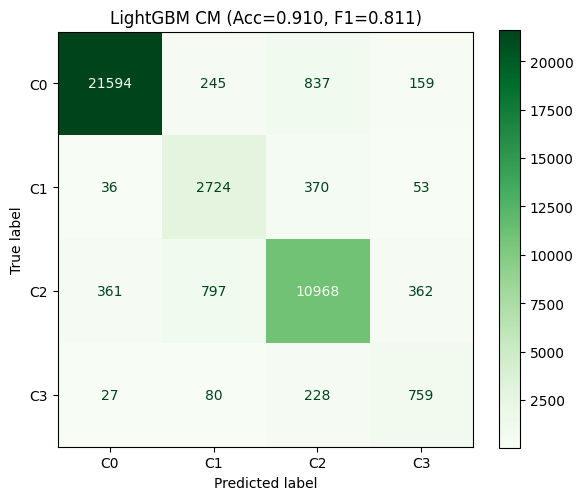

In [35]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=400,
    max_depth=7,
    learning_rate=0.1,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight=weights,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2
)
lgb_model.fit(X_tr, y_tr,eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(30, verbose=False),
               lgb.log_evaluation(period=-1)])

y_pred_lgb = lgb_model.predict(X_val)
acc_lgb = accuracy_score(y_val, y_pred_lgb)
f1_lgb = f1_score(y_val, y_pred_lgb, average='macro')
print(f"\nLightGBM — Val Accuracy: {acc_lgb:.4f} | Macro-F1: {f1_lgb:.4f}")
print(classification_report(y_val, y_pred_lgb))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred_lgb),
                       display_labels=[f"C{i}" for i in range(4)]).plot(ax=ax, cmap='Greens')
ax.set_title(f"LightGBM CM (Acc={acc_lgb:.3f}, F1={f1_lgb:.3f})")
plt.tight_layout() #plt.savefig("lgb_cm.png", dpi=150); 
plt.show()

## 5.2 Complement Naive Bayes

Fitting 2 folds for each of 5 candidates, totalling 10 fits
[CV] END .........................................alpha=0.01; total time=   0.1s
[CV] END .........................................alpha=0.01; total time=   0.1s
[CV] END ..........................................alpha=0.1; total time=   0.1s
[CV] END ..........................................alpha=0.1; total time=   0.1s
[CV] END ..........................................alpha=0.5; total time=   0.1s
[CV] END ..........................................alpha=0.5; total time=   0.1s
[CV] END ..........................................alpha=1.0; total time=   0.1s
[CV] END ..........................................alpha=1.0; total time=   0.1s
[CV] END ..........................................alpha=2.0; total time=   0.1s
[CV] END ..........................................alpha=2.0; total time=   0.1s
Best NB params : {'alpha': 0.01}
Best CV F1     : 0.1561

Complement Naive Bayes — Acc: 0.1883 | Macro-F1: 0.1481
              pr

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


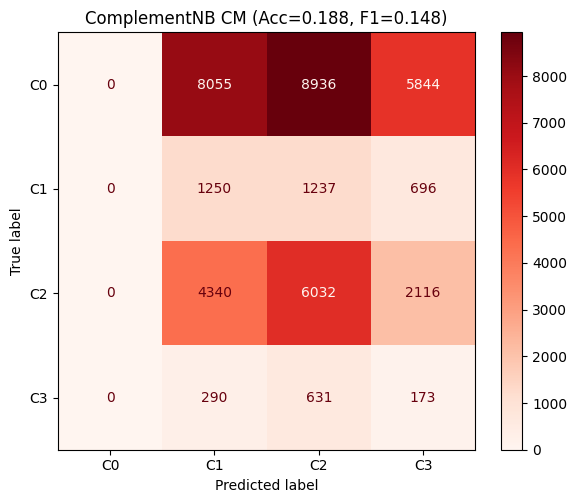

In [ ]:
from sklearn.naive_bayes import ComplementNB
from sklearn.model_selection import GridSearchCV

param_grid_nb = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0],
}

nb_search = GridSearchCV(
    ComplementNB(),
    param_grid=param_grid_nb,
    cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro',
    n_jobs=1,
    verbose=2
)
nb_search.fit(X_tr_nb, y_tr_nb)

print(f"Best NB params : {nb_search.best_params_}")
print(f"Best CV F1     : {nb_search.best_score_:.4f}")

nb_tuned = ComplementNB(alpha=nb_search.best_params_['alpha'])
nb_tuned.fit(X_tr_nb, y_tr_nb)

y_pred_nb = nb_tuned.predict(X_val_nb)
acc_nb    = accuracy_score(y_val_nb, y_pred_nb)
f1_nb     = f1_score(y_val_nb, y_pred_nb, average='macro')
print(f"\nComplement Naive Bayes — Acc: {acc_nb:.4f} | Macro-F1: {f1_nb:.4f}")
print(classification_report(y_val_nb, y_pred_nb))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_val_nb, y_pred_nb),
                       display_labels=[f"C{i}" for i in range(4)]).plot(ax=ax, cmap='Reds')
ax.set_title(f"ComplementNB CM (Acc={acc_nb:.3f}, F1={f1_nb:.3f})")
plt.tight_layout(); plt.show()

## 5.3 XGBoost 

#### Hyperparameter tuning

```
from sklearn.model_selection import RandomizedSearchCV

param_dist_xgb = {
    'n_estimators':[200, 400],
    'max_depth':[4, 6],
    'learning_rate':[0.05, 0.1],
}

sample_weights_tr = np.array([weights[yy] for yy in y_tr])

xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbosity=0
    ),
    param_distributions=param_dist_xgb,
    n_iter=15,
    cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro',
    n_jobs=1,        # XGB already uses n_jobs=-1 internally
    verbose=2,
    random_state=RANDOM_STATE
)
xgb_search.fit(X_tr, y_tr, sample_weight=sample_weights_tr)

print(f"Best XGB params : {xgb_search.best_params_}")
print(f"Best CV F1 : {xgb_search.best_score_:.4f}")

results_xgb_tune = pd.DataFrame(xgb_search.cv_results_)[
    ['param_n_estimators','param_max_depth','param_learning_rate','mean_test_score']
].sort_values('mean_test_score', ascending=False)
print("\nTop 5:"); print(results_xgb_tune.head().to_string(index=False))
```
***OUTPUT:***

Best XGB params : {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.1}

Best CV F1      : 0.8430

Top 5:
| param_n_estimators | param_max_depth | param_learning_rate | mean_test_score |
|--------------------|------------------|----------------------|-----------------|
| 400                | 4                | 0.10                 | 0.842998        |
| 400                | 4                | 0.05                 | 0.837504        |
| 200                | 4                | 0.10                 | 0.835183        |
| 400                | 6                | 0.05                 | 0.835160        |
| 200                | 6                | 0.10                 | 0.834824        |

```
sample_weights_full = np.array([weights[yy] for yy in y_tr])

xgb_tuned = xgb.XGBClassifier(
    **xgb_search.best_params_,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    early_stopping_rounds=30,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb_tuned.fit(X_tr, y_tr,
              sample_weight=sample_weights_full,
              eval_set=[(X_val, y_val)],
              verbose=50)

y_pred_xgb = xgb_tuned.predict(X_val)
acc_xgb = accuracy_score(y_val, y_pred_xgb)
f1_xgb = f1_score(y_val, y_pred_xgb, average='macro')
print(f"Tuned XGBoost — Acc: {acc_xgb:.4f} | Macro-F1: {f1_xgb:.4f}")
print(classification_report(y_val, y_pred_xgb))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred_xgb),
                       display_labels=[f"C{i}" for i in range(4)]).plot(ax=ax, cmap='Oranges')
ax.set_title(f"XGBoost CM (Acc={acc_xgb:.3f}, F1={f1_xgb:.3f})")
plt.tight_layout(); plt.show()

```

[0]	validation_0-mlogloss:1.27052
[50]	validation_0-mlogloss:0.46398
[100]	validation_0-mlogloss:0.41460
[150]	validation_0-mlogloss:0.38900
[200]	validation_0-mlogloss:0.37238
[250]	validation_0-mlogloss:0.36046
[300]	validation_0-mlogloss:0.35136
[350]	validation_0-mlogloss:0.34413
[399]	validation_0-mlogloss:0.33826
Tuned XGBoost — Acc: 0.8954 | Macro-F1: 0.7814
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     22835
           1       0.67      0.87      0.76      3183
           2       0.90      0.82      0.86     12488
           3       0.42      0.79      0.55      1094

    accuracy                           0.90     39600
   macro avg       0.74      0.86      0.78     39600
weighted avg       0.91      0.90      0.90     39600



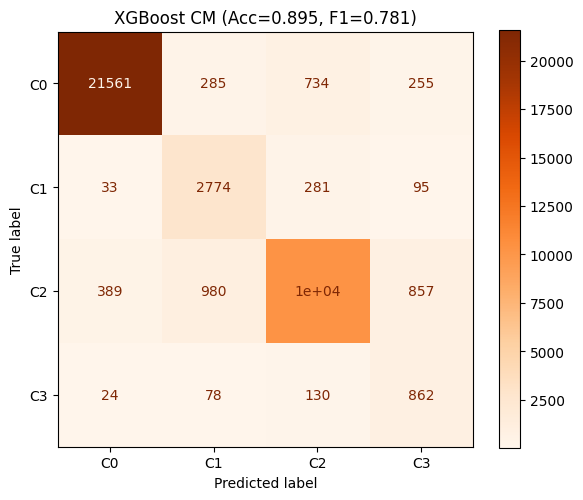

In [37]:
sample_weights_full = np.array([weights[yy] for yy in y_tr])

xgb_tuned = xgb.XGBClassifier(
    n_estimators = 400,
    max_depth = 4,
    learning_rate = 0.10,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    early_stopping_rounds=30,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb_tuned.fit(X_tr, y_tr,
              sample_weight=sample_weights_full,
              eval_set=[(X_val, y_val)],
              verbose=50)

y_pred_xgb = xgb_tuned.predict(X_val)
acc_xgb    = accuracy_score(y_val, y_pred_xgb)
f1_xgb     = f1_score(y_val, y_pred_xgb, average='macro')
print(f"Tuned XGBoost — Acc: {acc_xgb:.4f} | Macro-F1: {f1_xgb:.4f}")
print(classification_report(y_val, y_pred_xgb))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred_xgb),
                       display_labels=[f"C{i}" for i in range(4)]).plot(ax=ax, cmap='Oranges')
ax.set_title(f"XGBoost CM (Acc={acc_xgb:.3f}, F1={f1_xgb:.3f})")
plt.tight_layout(); plt.show()

## 5.4 Model Comparison

        Model  Val Acc  Macro F1
 LGB Baseline 0.910227  0.811175
XGBoost Tuned 0.895429  0.781405


/tmp/ipykernel_17/1191504347.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_compare['Model'], rotation=10, ha='right')
/tmp/ipykernel_17/1191504347.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_compare['Model'], rotation=10, ha='right')


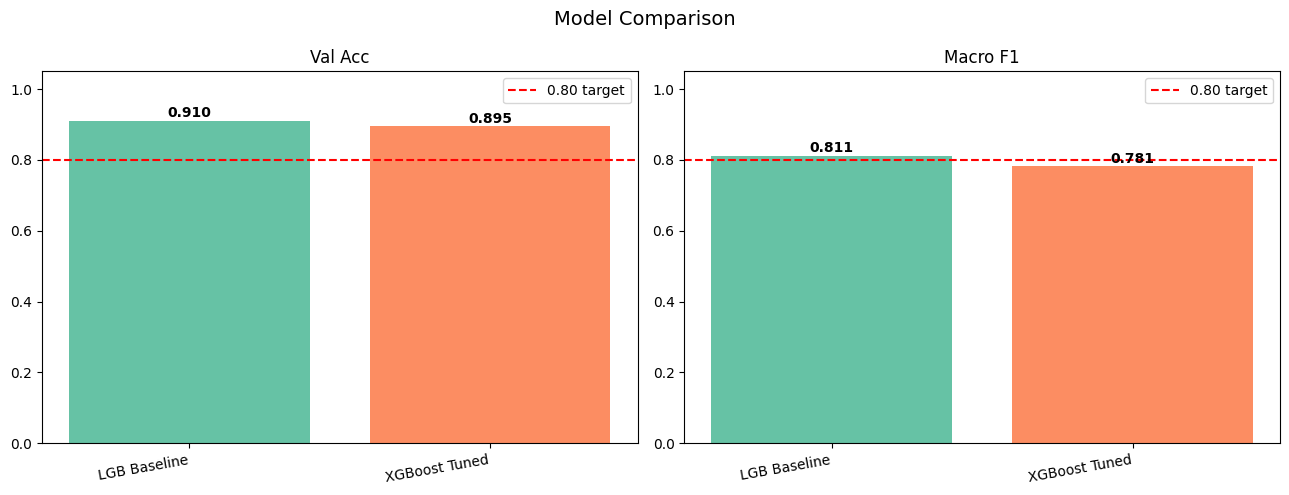

In [38]:
results_compare = pd.DataFrame({
    'Model':['LGB Baseline', 'XGBoost Tuned'],
    'Val Acc':[acc_lgb, acc_xgb],
    'Macro F1':[f1_lgb, f1_xgb],
})
print(results_compare.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ['Val Acc', 'Macro F1']):
    bars = ax.bar(results_compare['Model'], results_compare[metric],
                  color=sns.color_palette('Set2', 2))
    ax.axhline(0.80, color='red', linestyle='--', linewidth=1.5, label='0.80 target')
    ax.set_ylim(0, 1.05); ax.set_title(metric)
    ax.set_xticklabels(results_compare['Model'], rotation=10, ha='right')
    ax.legend()
    for bar, val in zip(bars, results_compare[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
plt.suptitle('Model Comparison', fontsize=14)
plt.tight_layout(); plt.show()


## 5.5 Soft Voting Ensemble

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Ensemble candidates:
 LGB_base + XGB (50/50)                  : acc=0.9066, F1=0.8043, class3=0.6066
 LGB_base + XGB (60/40)                  : acc=0.9080, F1=0.8079, class3=0.6173
 LGB_base + XGB (70/30)                  : acc=0.9088, F1=0.8087, class3=0.6187

Best: LGB_base + XGB (70/30) -> macro-F1=0.8087
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.70      0.86      0.77      3183
           2       0.89      0.87      0.88     12488
           3       0.54      0.72      0.62      1094

    accuracy                           0.91     39600
   macro avg       0.78      0.85      0.81     39600
weighted avg       0.92      0.91      0.91     39600



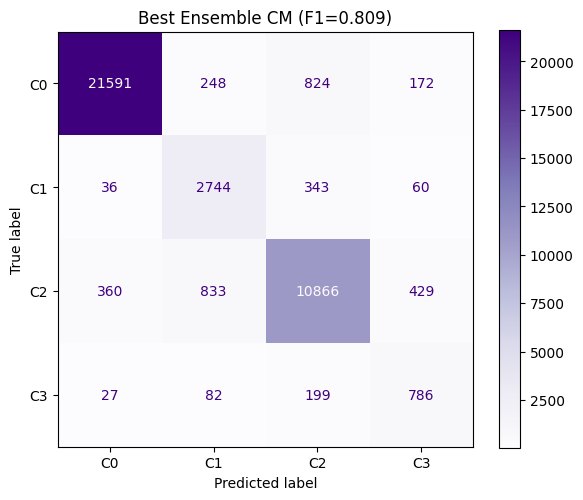

In [39]:
proba_lgb_base = lgb_model.predict_proba(X_val)
proba_xgb_val = xgb_tuned.predict_proba(X_val)

candidates = [
    ('LGB_base + XGB (50/50)',0.5*proba_lgb_base  + 0.5*proba_xgb_val),
    ('LGB_base + XGB (60/40)',0.6*proba_lgb_base + 0.4*proba_xgb_val),
    ('LGB_base + XGB (70/30)',0.7*proba_lgb_base + 0.3*proba_xgb_val),
]

best_ens_f1 = 0
best_ens_proba = None
best_ens_name = ''

print("Ensemble candidates:")
for name, proba in candidates:
    preds = np.argmax(proba, axis=1)
    f1 = f1_score(y_val, preds, average='macro')
    acc = accuracy_score(y_val, preds)
    c3_f1 = f1_score(y_val, preds, average=None)[3]
    print(f" {name:40s}: acc={acc:.4f}, F1={f1:.4f}, class3={c3_f1:.4f}")
    if f1 > best_ens_f1:
        best_ens_f1 = f1; best_ens_proba = proba; best_ens_name = name

print(f"\nBest: {best_ens_name} -> macro-F1={best_ens_f1:.4f}")
y_pred_ens = np.argmax(best_ens_proba, axis=1)
print(classification_report(y_val, y_pred_ens))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred_ens),
                       display_labels=[f"C{i}" for i in range(4)]).plot(ax=ax, cmap='Purples')
ax.set_title(f"Best Ensemble CM (F1={best_ens_f1:.3f})")
plt.tight_layout(); plt.show()


## 6. SUBMISSION

In [40]:
# Pick best model by macro-F1
scores = {
    'lgb_baseline':f1_lgb,
    'xgb_tuned':f1_xgb,
    'ensemble':best_ens_f1,
}
best_name = max(scores, key=scores.get)
print(f"All scores: {scores}")
print(f"Best: {best_name} -> {scores[best_name]:.4f}")

p_lgb_test = lgb_model.predict_proba(X_test)
p_xgb_test = xgb_tuned.predict_proba(X_test)

if best_name == 'lgb_baseline':
    y_test_pred = lgb_model.predict(X_test)
elif best_name == 'xgb_tuned':
    y_test_pred = xgb_tuned.predict(X_test)
else:
    # Reproduce best ensemble on test
    if '50/50' in best_ens_name and 'base' in best_ens_name:
        test_proba = 0.5*p_lgb_test + 0.5*p_xgb_test
    elif '60/40' in best_ens_name:
        test_proba = 0.6*p_lgb_test + 0.4*p_xgb_test
    elif '70/30' in best_ens_name:
        test_proba = 0.7*p_lgb_test + 0.3*p_xgb_test
    y_test_pred = np.argmax(test_proba, axis=1)

print(f"\nTest distribution: {np.bincount(y_test_pred)}")
for i in range(4):
    print(f"  Class {i}: test={( y_test_pred==i).mean():.3f}, train={(y==i).mean():.3f}")

sample_sub = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
submission = sample_sub.copy()
submission['label'] = y_test_pred
submission.to_csv("submission.csv", index=False)
print(f"\nsubmission.csv saved")
print(submission['label'].value_counts().sort_index())
print(submission.head())


All scores: {'lgb_baseline': 0.8111748385575709, 'xgb_tuned': 0.7814049323246133, 'ensemble': 0.8086647685015791}
Best: lgb_baseline -> 0.8112


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Test distribution: [56615  9619 32330  3436]
  Class 0: test=0.555, train=0.577
  Class 1: test=0.094, train=0.080
  Class 2: test=0.317, train=0.315
  Class 3: test=0.034, train=0.028

submission.csv saved
label
0    56615
1     9619
2    32330
3     3436
Name: count, dtype: int64
   ID  label
0   1      2
1   2      2
2   3      0
3   4      0
4   5      2
